In [2]:
# ================================
# SETUP
# ================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

# Optional: if available
# from umap import UMAP

In [3]:
# ================================
# LOAD DATA
# ================================

DATA_PATH = "../data/raw"

splits = ["reference", "finetune", "test", "2018clinical", "2019clinical"]

data = {}

for split in splits:
    try:
        X_path = os.path.join(DATA_PATH, f"X_{split}.npy")
        y_path = os.path.join(DATA_PATH, f"y_{split}.npy")
        
        X = np.load(X_path)
        y = np.load(y_path)
        
        data[split] = {"X": X, "y": y}
        
        print(f"{split}: X {X.shape}, y {y.shape}")
        
    except Exception as e:
        print(f"{split} not loaded: {e}")

reference: X (60000, 1000), y (60000,)
finetune: X (3000, 1000), y (3000,)
test: X (3000, 1000), y (3000,)
2018clinical: X (10000, 1000), y (10000,)
2019clinical: X (2500, 1000), y (2500,)


In [4]:
# ================================
# SANITY CHECK
# ================================

for split in data:
    X = data[split]["X"]
    y = data[split]["y"]
    
    print(f"\n--- {split} ---")
    print("Samples:", len(X))
    print("Features per sample:", X.shape[1])
    print("Unique classes:", np.unique(y))
    
    assert len(X) == len(y), "Mismatch in X and y"


--- reference ---
Samples: 60000
Features per sample: 1000
Unique classes: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]

--- finetune ---
Samples: 3000
Features per sample: 1000
Unique classes: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]

--- test ---
Samples: 3000
Features per sample: 1000
Unique classes: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]

--- 2018clinical ---
Samples: 10000
Features per sample: 1000
Unique classes: [0. 2. 3. 5. 6.]

--- 2019clinical ---
Samples: 2500
Features per sample: 1000
Unique classes: [0. 2. 3. 5. 6.]



Split: reference
Counter({np.float64(0.0): 2000, np.float64(1.0): 2000, np.float64(2.0): 2000, np.float64(3.0): 2000, np.float64(4.0): 2000, np.float64(5.0): 2000, np.float64(6.0): 2000, np.float64(7.0): 2000, np.float64(8.0): 2000, np.float64(9.0): 2000, np.float64(10.0): 2000, np.float64(11.0): 2000, np.float64(12.0): 2000, np.float64(13.0): 2000, np.float64(14.0): 2000, np.float64(15.0): 2000, np.float64(16.0): 2000, np.float64(17.0): 2000, np.float64(18.0): 2000, np.float64(19.0): 2000, np.float64(20.0): 2000, np.float64(21.0): 2000, np.float64(22.0): 2000, np.float64(23.0): 2000, np.float64(24.0): 2000, np.float64(25.0): 2000, np.float64(26.0): 2000, np.float64(27.0): 2000, np.float64(28.0): 2000, np.float64(29.0): 2000})


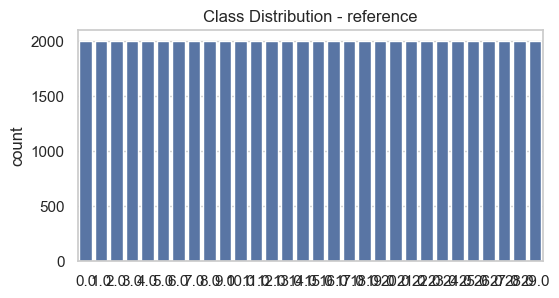


Split: finetune
Counter({np.float64(0.0): 100, np.float64(1.0): 100, np.float64(2.0): 100, np.float64(3.0): 100, np.float64(4.0): 100, np.float64(5.0): 100, np.float64(6.0): 100, np.float64(7.0): 100, np.float64(8.0): 100, np.float64(9.0): 100, np.float64(10.0): 100, np.float64(11.0): 100, np.float64(12.0): 100, np.float64(13.0): 100, np.float64(14.0): 100, np.float64(15.0): 100, np.float64(16.0): 100, np.float64(17.0): 100, np.float64(18.0): 100, np.float64(19.0): 100, np.float64(20.0): 100, np.float64(21.0): 100, np.float64(22.0): 100, np.float64(23.0): 100, np.float64(24.0): 100, np.float64(25.0): 100, np.float64(26.0): 100, np.float64(27.0): 100, np.float64(28.0): 100, np.float64(29.0): 100})


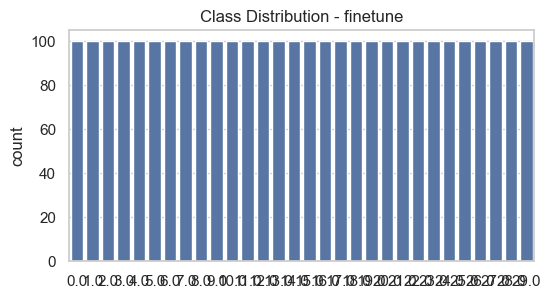


Split: test
Counter({np.float64(0.0): 100, np.float64(1.0): 100, np.float64(2.0): 100, np.float64(3.0): 100, np.float64(4.0): 100, np.float64(5.0): 100, np.float64(6.0): 100, np.float64(7.0): 100, np.float64(8.0): 100, np.float64(9.0): 100, np.float64(10.0): 100, np.float64(11.0): 100, np.float64(12.0): 100, np.float64(13.0): 100, np.float64(14.0): 100, np.float64(15.0): 100, np.float64(16.0): 100, np.float64(17.0): 100, np.float64(18.0): 100, np.float64(19.0): 100, np.float64(20.0): 100, np.float64(21.0): 100, np.float64(22.0): 100, np.float64(23.0): 100, np.float64(24.0): 100, np.float64(25.0): 100, np.float64(26.0): 100, np.float64(27.0): 100, np.float64(28.0): 100, np.float64(29.0): 100})


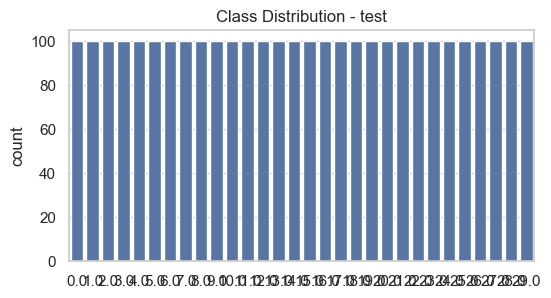


Split: 2018clinical
Counter({np.float64(0.0): 2000, np.float64(6.0): 2000, np.float64(5.0): 2000, np.float64(3.0): 2000, np.float64(2.0): 2000})


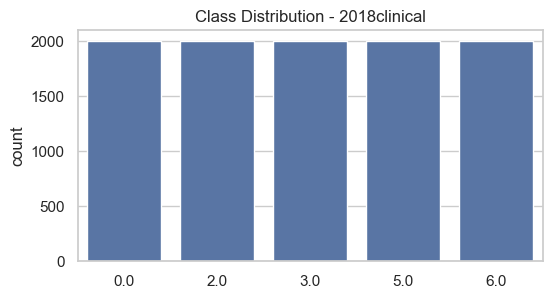


Split: 2019clinical
Counter({np.float64(0.0): 500, np.float64(5.0): 500, np.float64(6.0): 500, np.float64(3.0): 500, np.float64(2.0): 500})


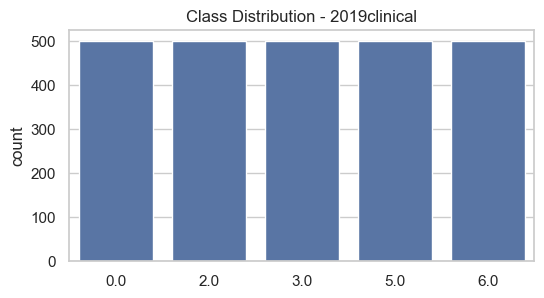

In [5]:
# ================================
# CLASS DISTRIBUTION
# ================================

for split in data:
    y = data[split]["y"]
    
    print(f"\nSplit: {split}")
    print(Counter(y))
    
    plt.figure(figsize=(6,3))
    sns.countplot(x=y)
    plt.title(f"Class Distribution - {split}")
    plt.show()

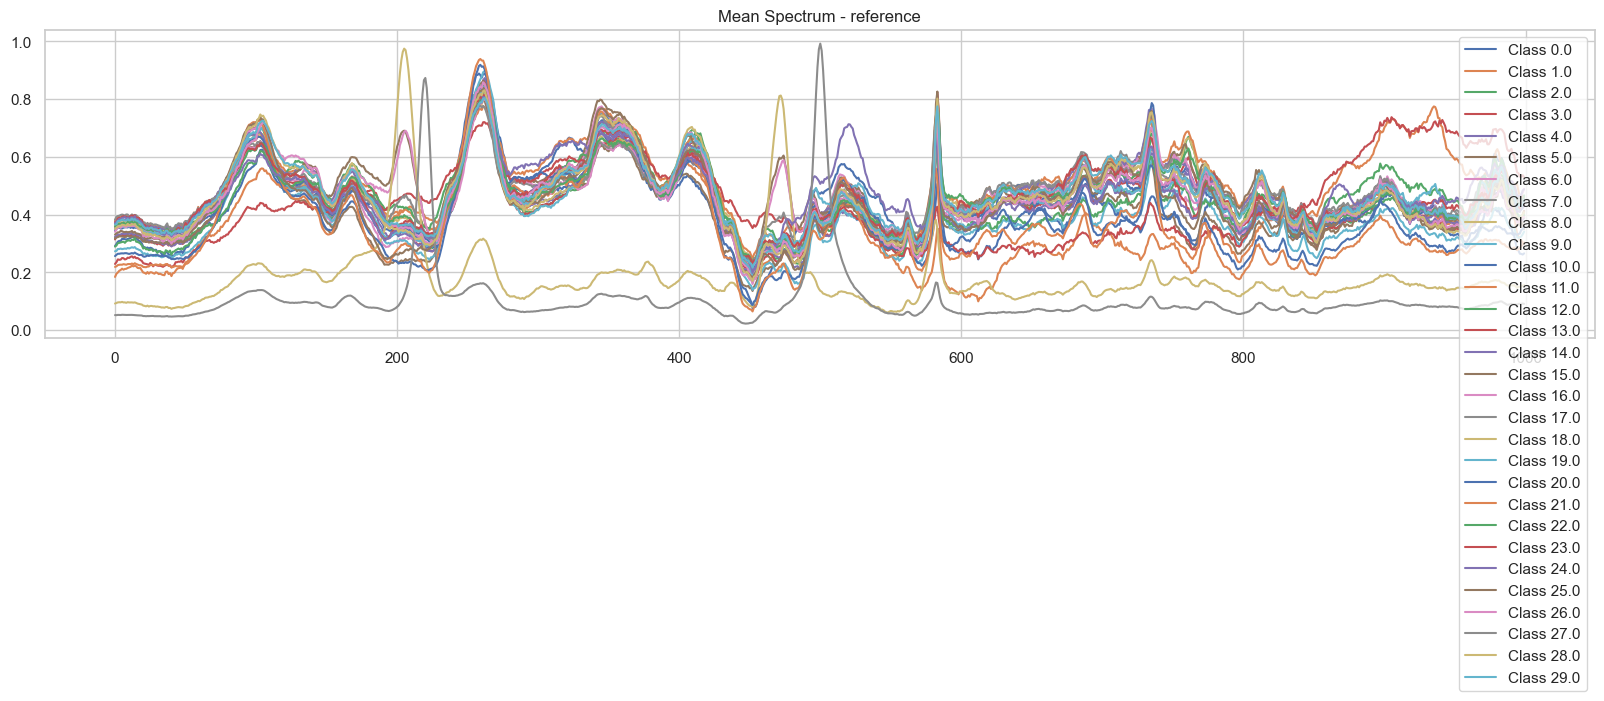

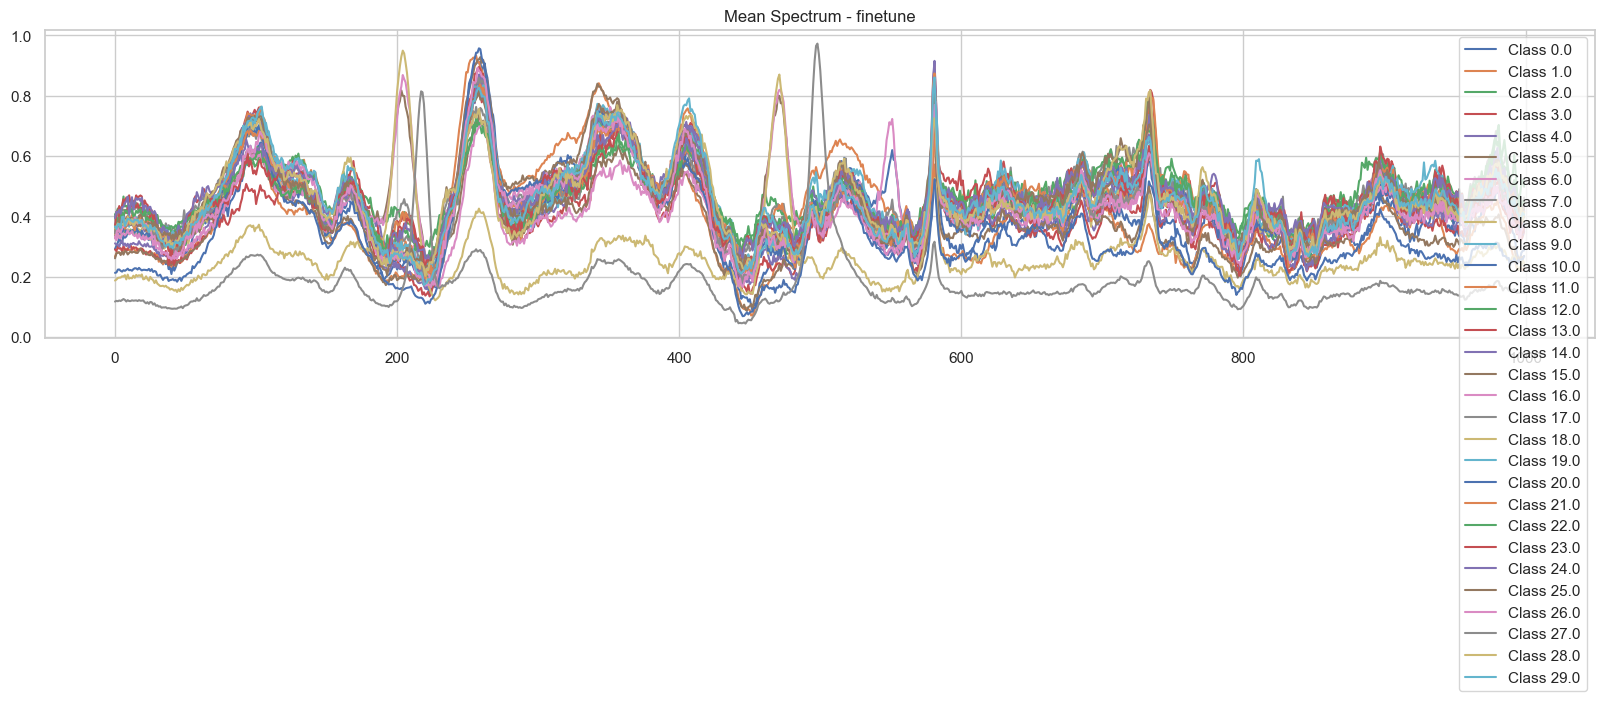

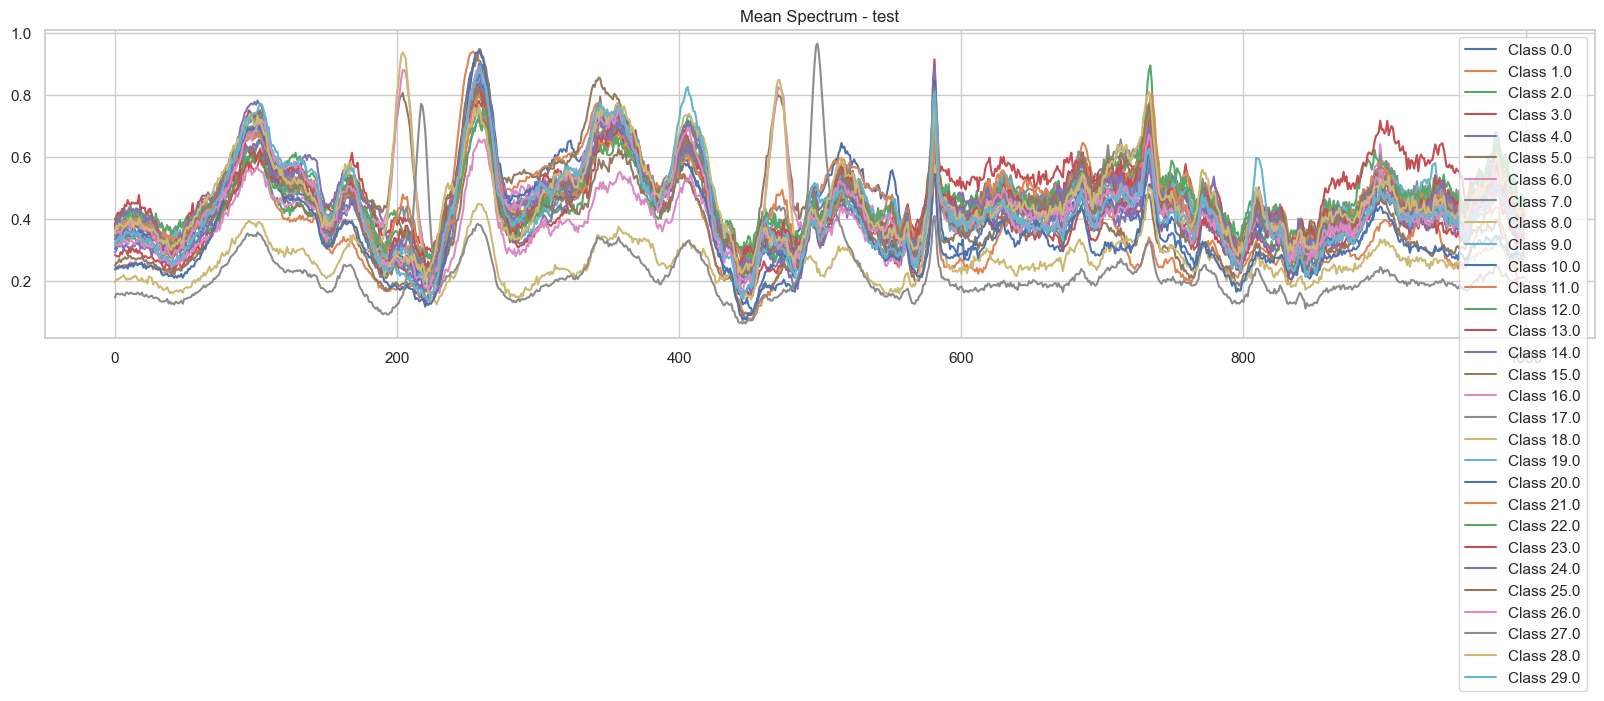

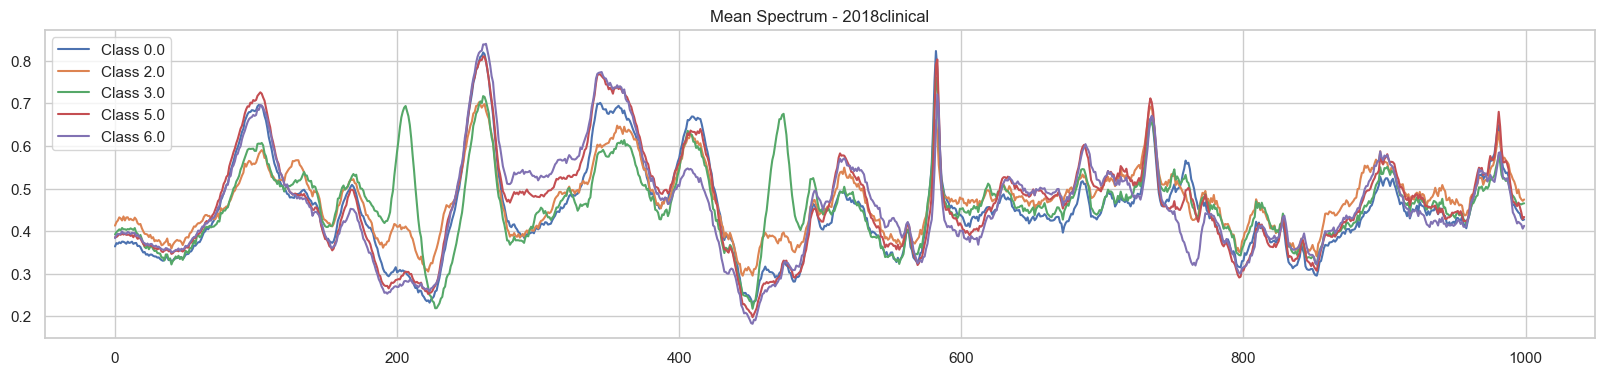

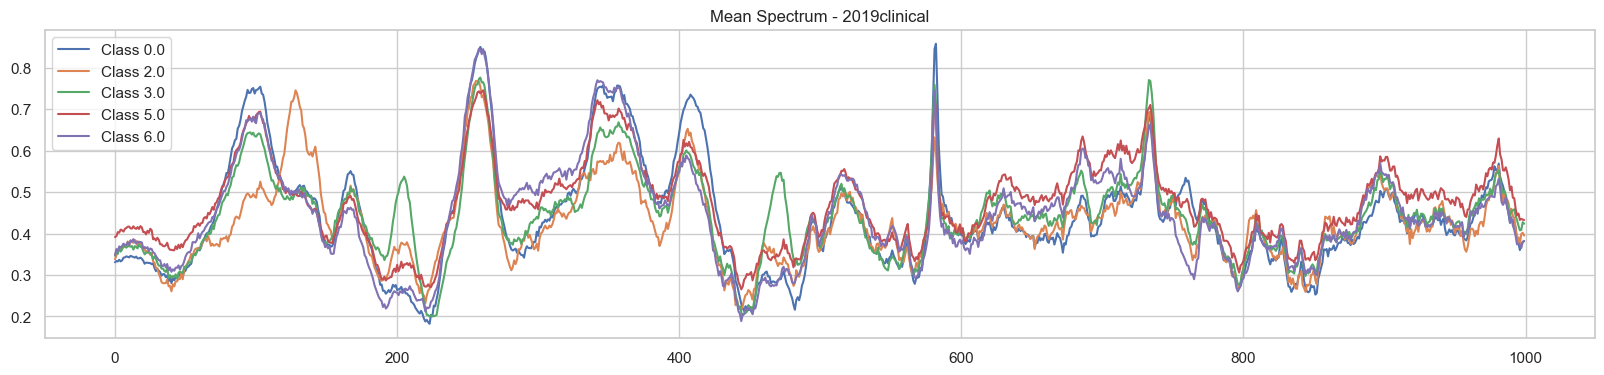

In [10]:
# ================================
# MEAN SPECTRUM PER CLASS
# ================================

for split in data:
    X = data[split]["X"]
    y = data[split]["y"]
    
    plt.figure(figsize=(20,4))
    
    for cls in np.unique(y):
        mean_signal = X[y == cls].mean(axis=0)
        plt.plot(mean_signal, label=f"Class {cls}")
    
    plt.title(f"Mean Spectrum - {split}")
    plt.legend()
    plt.show()

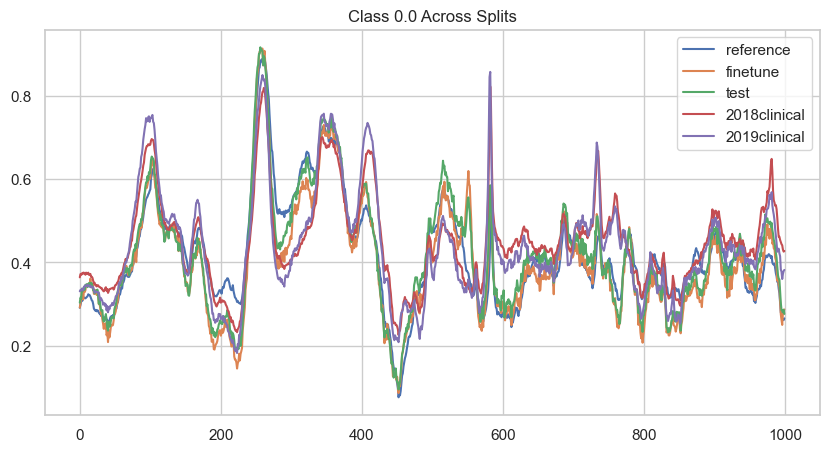

In [6]:
# ================================
# SAME CLASS ACROSS SPLITS
# ================================

target_class = np.unique(list(data.values())[0]["y"])[0]

plt.figure(figsize=(10,5))

for split in data:
    X = data[split]["X"]
    y = data[split]["y"]
    
    if target_class in y:
        mean_signal = X[y == target_class].mean(axis=0)
        plt.plot(mean_signal, label=split)

plt.title(f"Class {target_class} Across Splits")
plt.legend()
plt.show()

In [7]:
# ================================
# COMBINE DATA
# ================================

X_all = []
y_all = []
split_labels = []

for split in data:
    X = data[split]["X"]
    y = data[split]["y"]
    
    X_all.append(X)
    y_all.append(y)
    split_labels.extend([split] * len(X))

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
split_labels = np.array(split_labels)

In [8]:
# ================================
# PCA
# ================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

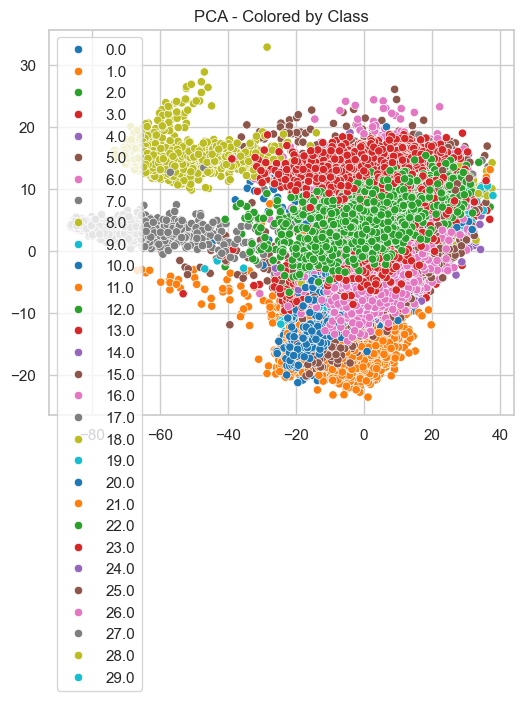

In [9]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_all, palette="tab10")
plt.title("PCA - Colored by Class")
plt.show()

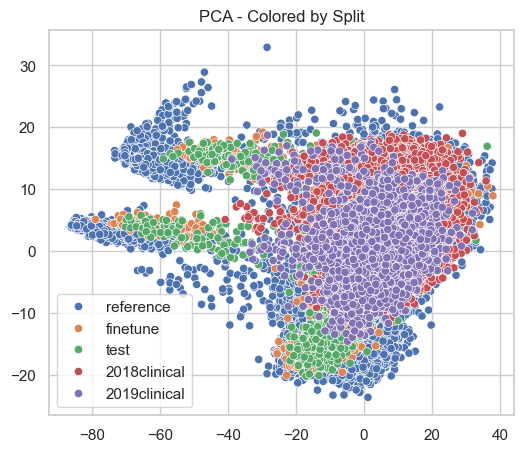

In [10]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=split_labels)
plt.title("PCA - Colored by Split")
plt.show()

In [11]:
# ================================
# VALUE RANGE CHECK
# ================================

for split in data:
    X = data[split]["X"]
    
    print(f"\n{split}")
    print("Min:", X.min())
    print("Max:", X.max())
    print("Mean:", X.mean())


reference
Min: 0.0
Max: 1.0
Mean: 0.4276437380614325

finetune
Min: 0.0
Max: 1.0
Mean: 0.4240386026634618

test
Min: 0.0
Max: 1.0
Mean: 0.42513455845384907

2018clinical
Min: 0.0
Max: 1.0
Mean: 0.4622007317122373

2019clinical
Min: 0.0
Max: 1.0
Mean: 0.4456405018126803


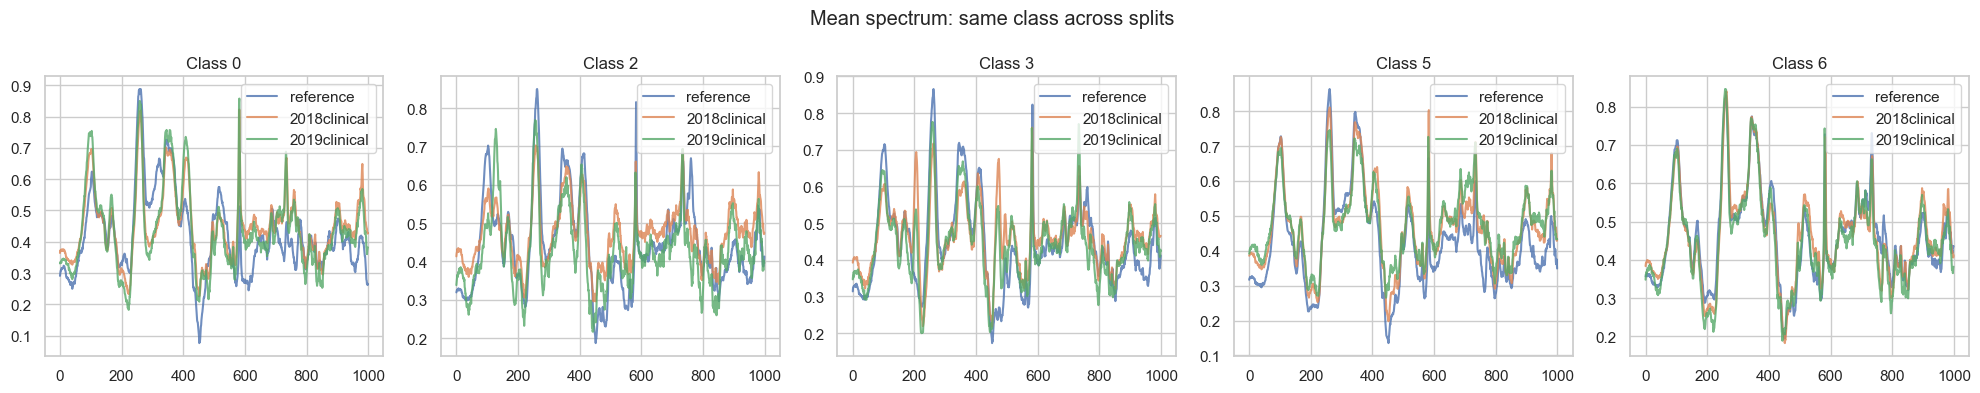

In [12]:
shared_classes = [0, 2, 3, 5, 6]
splits_to_compare = ["reference", "2018clinical", "2019clinical"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, cls in zip(axes, shared_classes):
    for split in splits_to_compare:
        X, y = data[split]["X"], data[split]["y"]
        mask = y == cls
        ax.plot(X[mask].mean(axis=0), label=split, alpha=0.8)
    ax.set_title(f"Class {cls}")
    ax.legend()
plt.suptitle("Mean spectrum: same class across splits")
plt.tight_layout()
plt.show()